In [1]:
import numpy as np
from scipy.signal import butter, filtfilt
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
import os

X = np.load("data/X.npy")
Y = np.load("data/Y.npy")

print(f"Loaded: X={X.shape}, Y={Y.shape}")


Loaded: X=(1947, 128, 3), Y=(1947,)


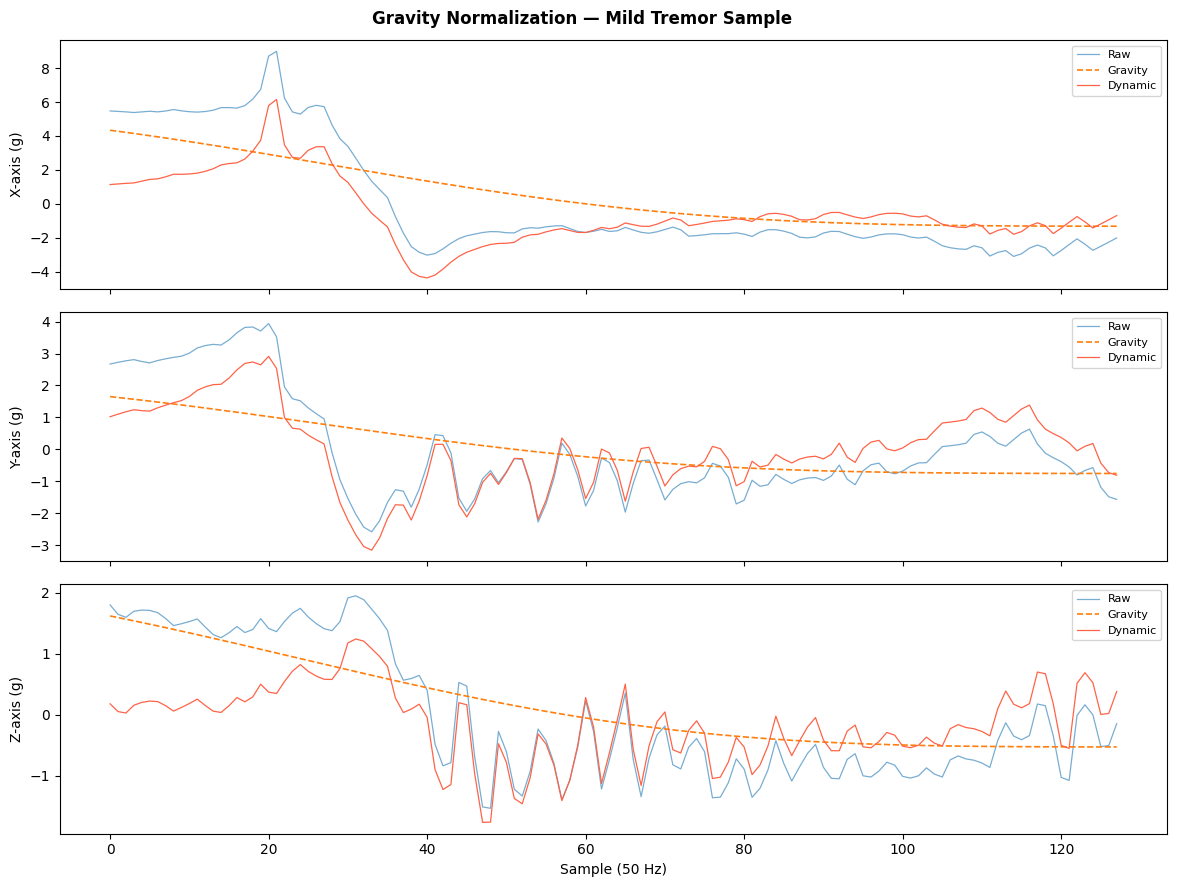

In [2]:
def gravity_normalize(window, fs=50, cutoff=0.3, order=4):
    nyq = fs / 2.0
    low = cutoff / nyq
    b, a = butter(order, low, btype="low")
    gravity = filtfilt(b, a, window, axis=0)
    dynamic = window - gravity
    return gravity, dynamic

idx_mild = np.where(Y == 1)[0][0]
sample = X[idx_mild]

gravity, dynamic = gravity_normalize(sample)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axis_labels = ["X", "Y", "Z"]

for i in range(3):
    axes[i].plot(sample[:, i], label="Raw", alpha=0.6, linewidth=0.9)
    axes[i].plot(gravity[:, i], label="Gravity", linewidth=1.2, linestyle="--")
    axes[i].plot(dynamic[:, i], label="Dynamic", linewidth=0.9, color="tomato")
    axes[i].set_ylabel(f"{axis_labels[i]}-axis (g)")
    axes[i].legend(fontsize=8, loc="upper right")

axes[2].set_xlabel("Sample (50 Hz)")
plt.suptitle("Gravity Normalization — Mild Tremor Sample", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/02_gravity_normalization.png", dpi=150, bbox_inches="tight")
plt.show()


In [3]:
def extract_features(window, fs=50):
    gravity, dynamic = gravity_normalize(window, fs=fs)

    features = []
    axis_labels = ["x", "y", "z"]

    for i in range(3):
        raw = window[:, i]
        grav = gravity[:, i]
        dyn = dynamic[:, i]

        for sig, prefix in [(raw, f"raw_{axis_labels[i]}"),
                             (grav, f"grav_{axis_labels[i]}"),
                             (dyn, f"dyn_{axis_labels[i]}")]:
            features.append(np.mean(sig))
            features.append(np.std(sig))
            features.append(np.min(sig))
            features.append(np.max(sig))
            features.append(np.max(sig) - np.min(sig))
            features.append(np.sqrt(np.mean(sig ** 2)))
            features.append(float(np.sum(np.abs(np.diff(sig)))))

            N = len(sig)
            fft_vals = np.abs(fft(sig))[:N // 2]
            freqs = fftfreq(N, d=1.0/fs)[:N // 2]
            features.append(float(np.sum(fft_vals ** 2) / N))
            dom_freq_idx = np.argmax(fft_vals[1:]) + 1
            features.append(float(freqs[dom_freq_idx]))
            tremor_mask = (freqs >= 3.0) & (freqs <= 12.0)
            features.append(float(np.sum(fft_vals[tremor_mask] ** 2)))

    gravity_mag = np.linalg.norm(gravity, axis=1)
    dynamic_mag = np.linalg.norm(dynamic, axis=1)
    features.append(np.mean(gravity_mag))
    features.append(np.std(gravity_mag))
    features.append(np.mean(dynamic_mag))
    features.append(np.std(dynamic_mag))
    features.append(float(np.sum(dynamic_mag ** 2) / len(dynamic_mag)))

    return np.array(features)


def get_feature_names():
    names = []
    axis_labels = ["x", "y", "z"]
    stats = ["mean", "std", "min", "max", "range", "rms", "activity_index",
             "spectral_power", "dominant_freq", "tremor_band_power"]
    for i in range(3):
        for prefix in [f"raw_{axis_labels[i]}", f"grav_{axis_labels[i]}", f"dyn_{axis_labels[i]}"]:
            for s in stats:
                names.append(f"{prefix}_{s}")
    names += ["grav_mag_mean", "grav_mag_std", "dyn_mag_mean", "dyn_mag_std", "dyn_mag_energy"]
    return names


sample_feat = extract_features(X[0])
feature_names = get_feature_names()
print(f"Features per window: {len(sample_feat)}")
print(f"Feature names count: {len(feature_names)}")


Features per window: 95
Feature names count: 95


In [4]:
print("Extracting features for all samples...")
feat_list = [extract_features(X[i]) for i in range(len(X))]
X_feat = np.array(feat_list)
print(f"Feature matrix shape: {X_feat.shape}")

nan_count = np.isnan(X_feat).sum()
inf_count = np.isinf(X_feat).sum()
print(f"NaN values: {nan_count}")
print(f"Inf values: {inf_count}")

if nan_count > 0 or inf_count > 0:
    X_feat = np.nan_to_num(X_feat, nan=0.0, posinf=0.0, neginf=0.0)
    print("Cleaned NaN/Inf values")

np.save("data/X_features.npy", X_feat)
np.save("data/feature_names.npy", np.array(feature_names))
print("Saved X_features.npy and feature_names.npy")


Extracting features for all samples...
Feature matrix shape: (1947, 95)
NaN values: 0
Inf values: 0
Saved X_features.npy and feature_names.npy


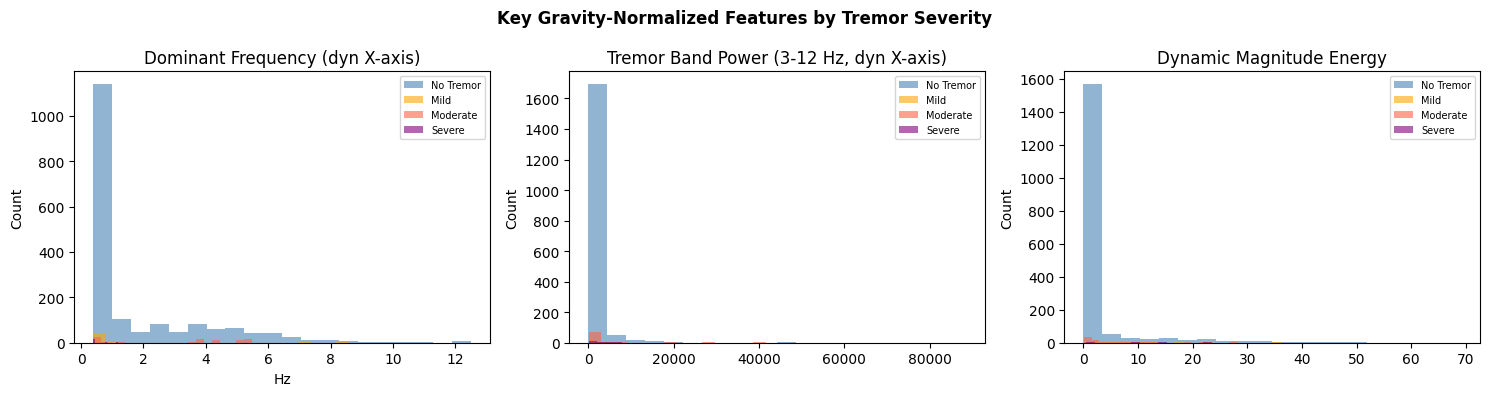

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

dominant_freq_idx = feature_names.index("dyn_x_dominant_freq")
tremor_power_idx = feature_names.index("dyn_x_tremor_band_power")
dyn_energy_idx = feature_names.index("dyn_mag_energy")

label_names = {0: "No Tremor", 1: "Mild", 2: "Moderate", 3: "Severe"}
colors = ["steelblue", "orange", "tomato", "purple"]

for cls in np.unique(Y):
    mask = Y == cls
    axes[0].hist(X_feat[mask, dominant_freq_idx], bins=20, alpha=0.6,
                 label=label_names[cls], color=colors[cls])
    axes[1].hist(X_feat[mask, tremor_power_idx], bins=20, alpha=0.6,
                 label=label_names[cls], color=colors[cls])
    axes[2].hist(X_feat[mask, dyn_energy_idx], bins=20, alpha=0.6,
                 label=label_names[cls], color=colors[cls])

axes[0].set_title("Dominant Frequency (dyn X-axis)")
axes[0].set_xlabel("Hz")
axes[1].set_title("Tremor Band Power (3-12 Hz, dyn X-axis)")
axes[2].set_title("Dynamic Magnitude Energy")
for ax in axes:
    ax.legend(fontsize=7)
    ax.set_ylabel("Count")

plt.suptitle("Key Gravity-Normalized Features by Tremor Severity", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/02_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
